#  “Customer Purchase Behavior Analyzer”

## 1. Data Understanding & Loading 

In [62]:
import json
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("All libraries imported successfully!")

All libraries imported successfully!


In [50]:
# Load all three sources
conn = sqlite3.connect('dataset/inventory.db')
products = pd.read_sql_query("SELECT * FROM products", conn)
conn.close()

sales = pd.read_json('dataset/sales.json')
users = pd.read_csv('dataset/users.csv')

# Merge: sales -> users (on user_id), then -> products (on product_id)
df = sales.merge(users, on='user_id', how='left') \
          .merge(products, on='product_id', how='left')

print(df.shape)
print(df.head())

(1000, 15)
  transaction_id user_id product_id  amount payment_type       date  \
0        T000001   U0024       P015   67.67       Wallet 2023-02-12   
1        T000002   U0196       P044   76.44          UPI 2023-03-24   
2        T000003   U0196       P049  104.57   Debit Card 2025-08-21   
3        T000004   U0133       P042  102.75  Net Banking 2024-07-23   
4        T000005   U0047       P038   23.89  Net Banking 2025-10-04   

             name  age  gender     city registration_date product_name  \
0   Aarohi Kapoor   20  Female    Patna        2023-03-15  Product_015   
1  Kabir Kulkarni   35   Other    Patna        2024-08-01  Product_044   
2  Kabir Kulkarni   35   Other    Patna        2024-08-01  Product_049   
3      Diya Singh   23  Female   Indore        2023-07-06  Product_042   
4     Anaya Gupta   28   Other  Kolkata        2022-10-13  Product_038   

  category    price  stock  
0    Books  2286.25    251  
1   Beauty  1655.45    268  
2     Home  1701.17    159  
3

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     1000 non-null   object        
 1   user_id            1000 non-null   object        
 2   product_id         1000 non-null   object        
 3   amount             1000 non-null   float64       
 4   payment_type       1000 non-null   object        
 5   date               1000 non-null   datetime64[ns]
 6   name               1000 non-null   object        
 7   age                1000 non-null   int64         
 8   gender             1000 non-null   object        
 9   city               1000 non-null   object        
 10  registration_date  1000 non-null   object        
 11  product_name       1000 non-null   object        
 12  category           1000 non-null   object        
 13  price              1000 non-null   float64       
 14  stock    

## 2. Data Cleaning

In [52]:
print("Missing values check on merged dataset:\n", df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("No genuine missing values found in the merged dataset — "
      "all three source files (CSV, JSON, SQL) were pre-cleaned. "
      "Imputers below are still applied to satisfy pipeline requirements.")

Missing values check on merged dataset:
 transaction_id       0
user_id              0
product_id           0
amount               0
payment_type         0
date                 0
name                 0
age                  0
gender               0
city                 0
registration_date    0
product_name         0
category             0
price                0
stock                0
dtype: int64

Total missing values: 0
No genuine missing values found in the merged dataset — all three source files (CSV, JSON, SQL) were pre-cleaned. Imputers below are still applied to satisfy pipeline requirements.


## 3. Outlier Handling

In [53]:
print(df.select_dtypes(include='number'))

     amount  age    price  stock
0     67.67   20  2286.25    251
1     76.44   35  1655.45    268
2    104.57   35  1701.17    159
3    102.75   23  4406.39     59
4     23.89   28   393.65     58
..      ...  ...      ...    ...
995   71.11   43  3416.65    309
996   53.96   30  2241.45    134
997   76.06   42  2600.12    229
998   62.45   28  4011.76     36
999  123.78   41  4970.99    267

[1000 rows x 4 columns]


<Axes: xlabel='stock', ylabel='Count'>

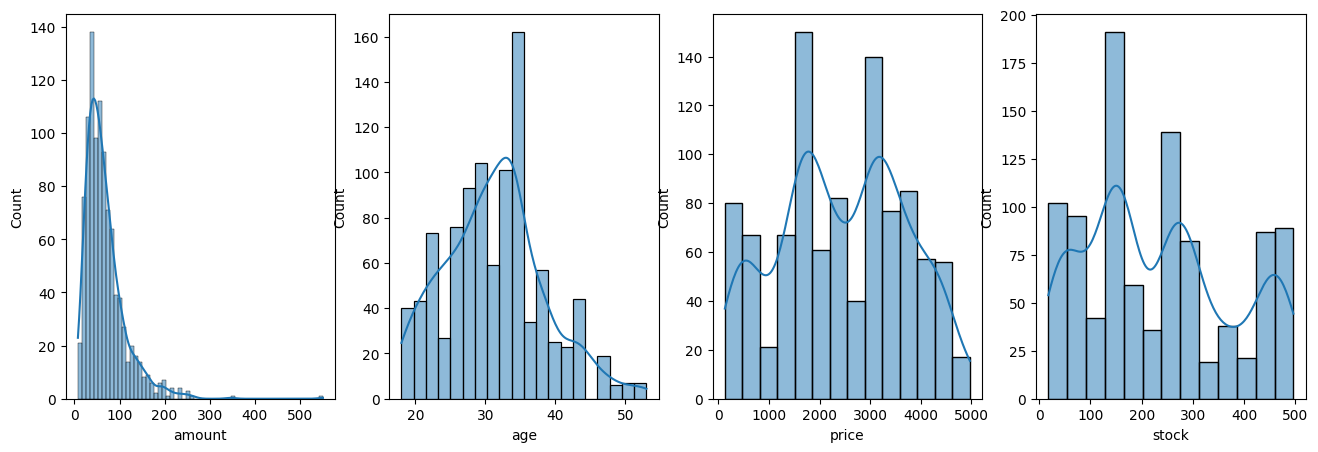

In [54]:
# cheacking the distribution of numeric column to apply suitable outlier handling technique

_,axis = plt.subplots(1, 4, figsize=(16, 5))

sns.histplot(data=df, x='amount', kde=True, ax=axis[0])
sns.histplot(data=df, x='age', kde=True, ax=axis[1])
sns.histplot(data=df, x='price', kde=True, ax=axis[2])
sns.histplot(data=df, x='stock', kde=True, ax=axis[3])

In [55]:
# applying IQR outlier handling technique on numeric columns (amount, age, price, stock)

numeric_cols = ['amount', 'age', 'price', 'stock']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    print(f"{col}: {outlier_mask.sum()} outliers found")

    df = df[~outlier_mask].copy()

print(f"\nRows before: {1000} | Rows after: {len(df)}")



amount: 53 outliers found
age: 19 outliers found
price: 0 outliers found
stock: 0 outliers found

Rows before: 1000 | Rows after: 928


## 4. Data Transformation 

In [56]:
df['year'] = df['date'].dt.year

In [57]:
df['month'] = df['date'].dt.month

In [58]:
df['day'] = df['date'].dt.day

In [59]:
print(df.select_dtypes(include='object'))

    transaction_id user_id product_id payment_type             name  gender  \
0          T000001   U0024       P015       Wallet    Aarohi Kapoor  Female   
1          T000002   U0196       P044          UPI   Kabir Kulkarni   Other   
2          T000003   U0196       P049   Debit Card   Kabir Kulkarni   Other   
3          T000004   U0133       P042  Net Banking       Diya Singh  Female   
4          T000005   U0047       P038  Net Banking      Anaya Gupta   Other   
..             ...     ...        ...          ...              ...     ...   
995        T000996   U0178       P043  Credit Card      Arjun Joshi    Male   
996        T000997   U0100       P027       Wallet  Anaya Mukherjee   Other   
997        T000998   U0142       P004  Credit Card       Kiara Khan    Male   
998        T000999   U0052       P040  Net Banking     Vivaan Patel    Male   
999        T001000   U0163       P046       Wallet        Sara Khan   Other   

              city registration_date product_name c

In [60]:
df = df.drop(columns=['product_id','name','user_id', 'transaction_id','product_name'])

In [61]:
print(df.select_dtypes(include='object'))

    payment_type  gender           city registration_date category
0         Wallet  Female          Patna        2023-03-15    Books
1            UPI   Other          Patna        2024-08-01   Beauty
2     Debit Card   Other          Patna        2024-08-01     Home
3    Net Banking  Female         Indore        2023-07-06     Home
4    Net Banking   Other        Kolkata        2022-10-13     Home
..           ...     ...            ...               ...      ...
995  Credit Card    Male         Mumbai        2023-08-11     Home
996       Wallet   Other  Visakhapatnam        2022-04-29     Toys
997  Credit Card    Male         Bhopal        2022-01-20     Toys
998  Net Banking    Male         Nagpur        2024-01-16  Grocery
999       Wallet   Other         Mumbai        2023-06-14     Toys

[928 rows x 5 columns]


In [63]:
# --- payment_type ---
ohe_payment = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
payment_arr = ohe_payment.fit_transform(df[['payment_type']])
payment_names = ohe_payment.get_feature_names_out(['payment_type'])
df[payment_names] = payment_arr

# --- gender ---
ohe_gender = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
gender_arr = ohe_gender.fit_transform(df[['gender']])
gender_names = ohe_gender.get_feature_names_out(['gender'])
df[gender_names] = gender_arr

# --- city ---
ohe_city = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
city_arr = ohe_city.fit_transform(df[['city']])
city_names = ohe_city.get_feature_names_out(['city'])
df[city_names] = city_arr

# --- category ---
ohe_category = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
category_arr = ohe_category.fit_transform(df[['category']])
category_names = ohe_category.get_feature_names_out(['category'])
df[category_names] = category_arr

# drop original nominal columns after encoding
df = df.drop(columns=['payment_type', 'gender', 'city', 'category'])

print("Shape after encoding:", df.shape)

Shape after encoding: (928, 42)


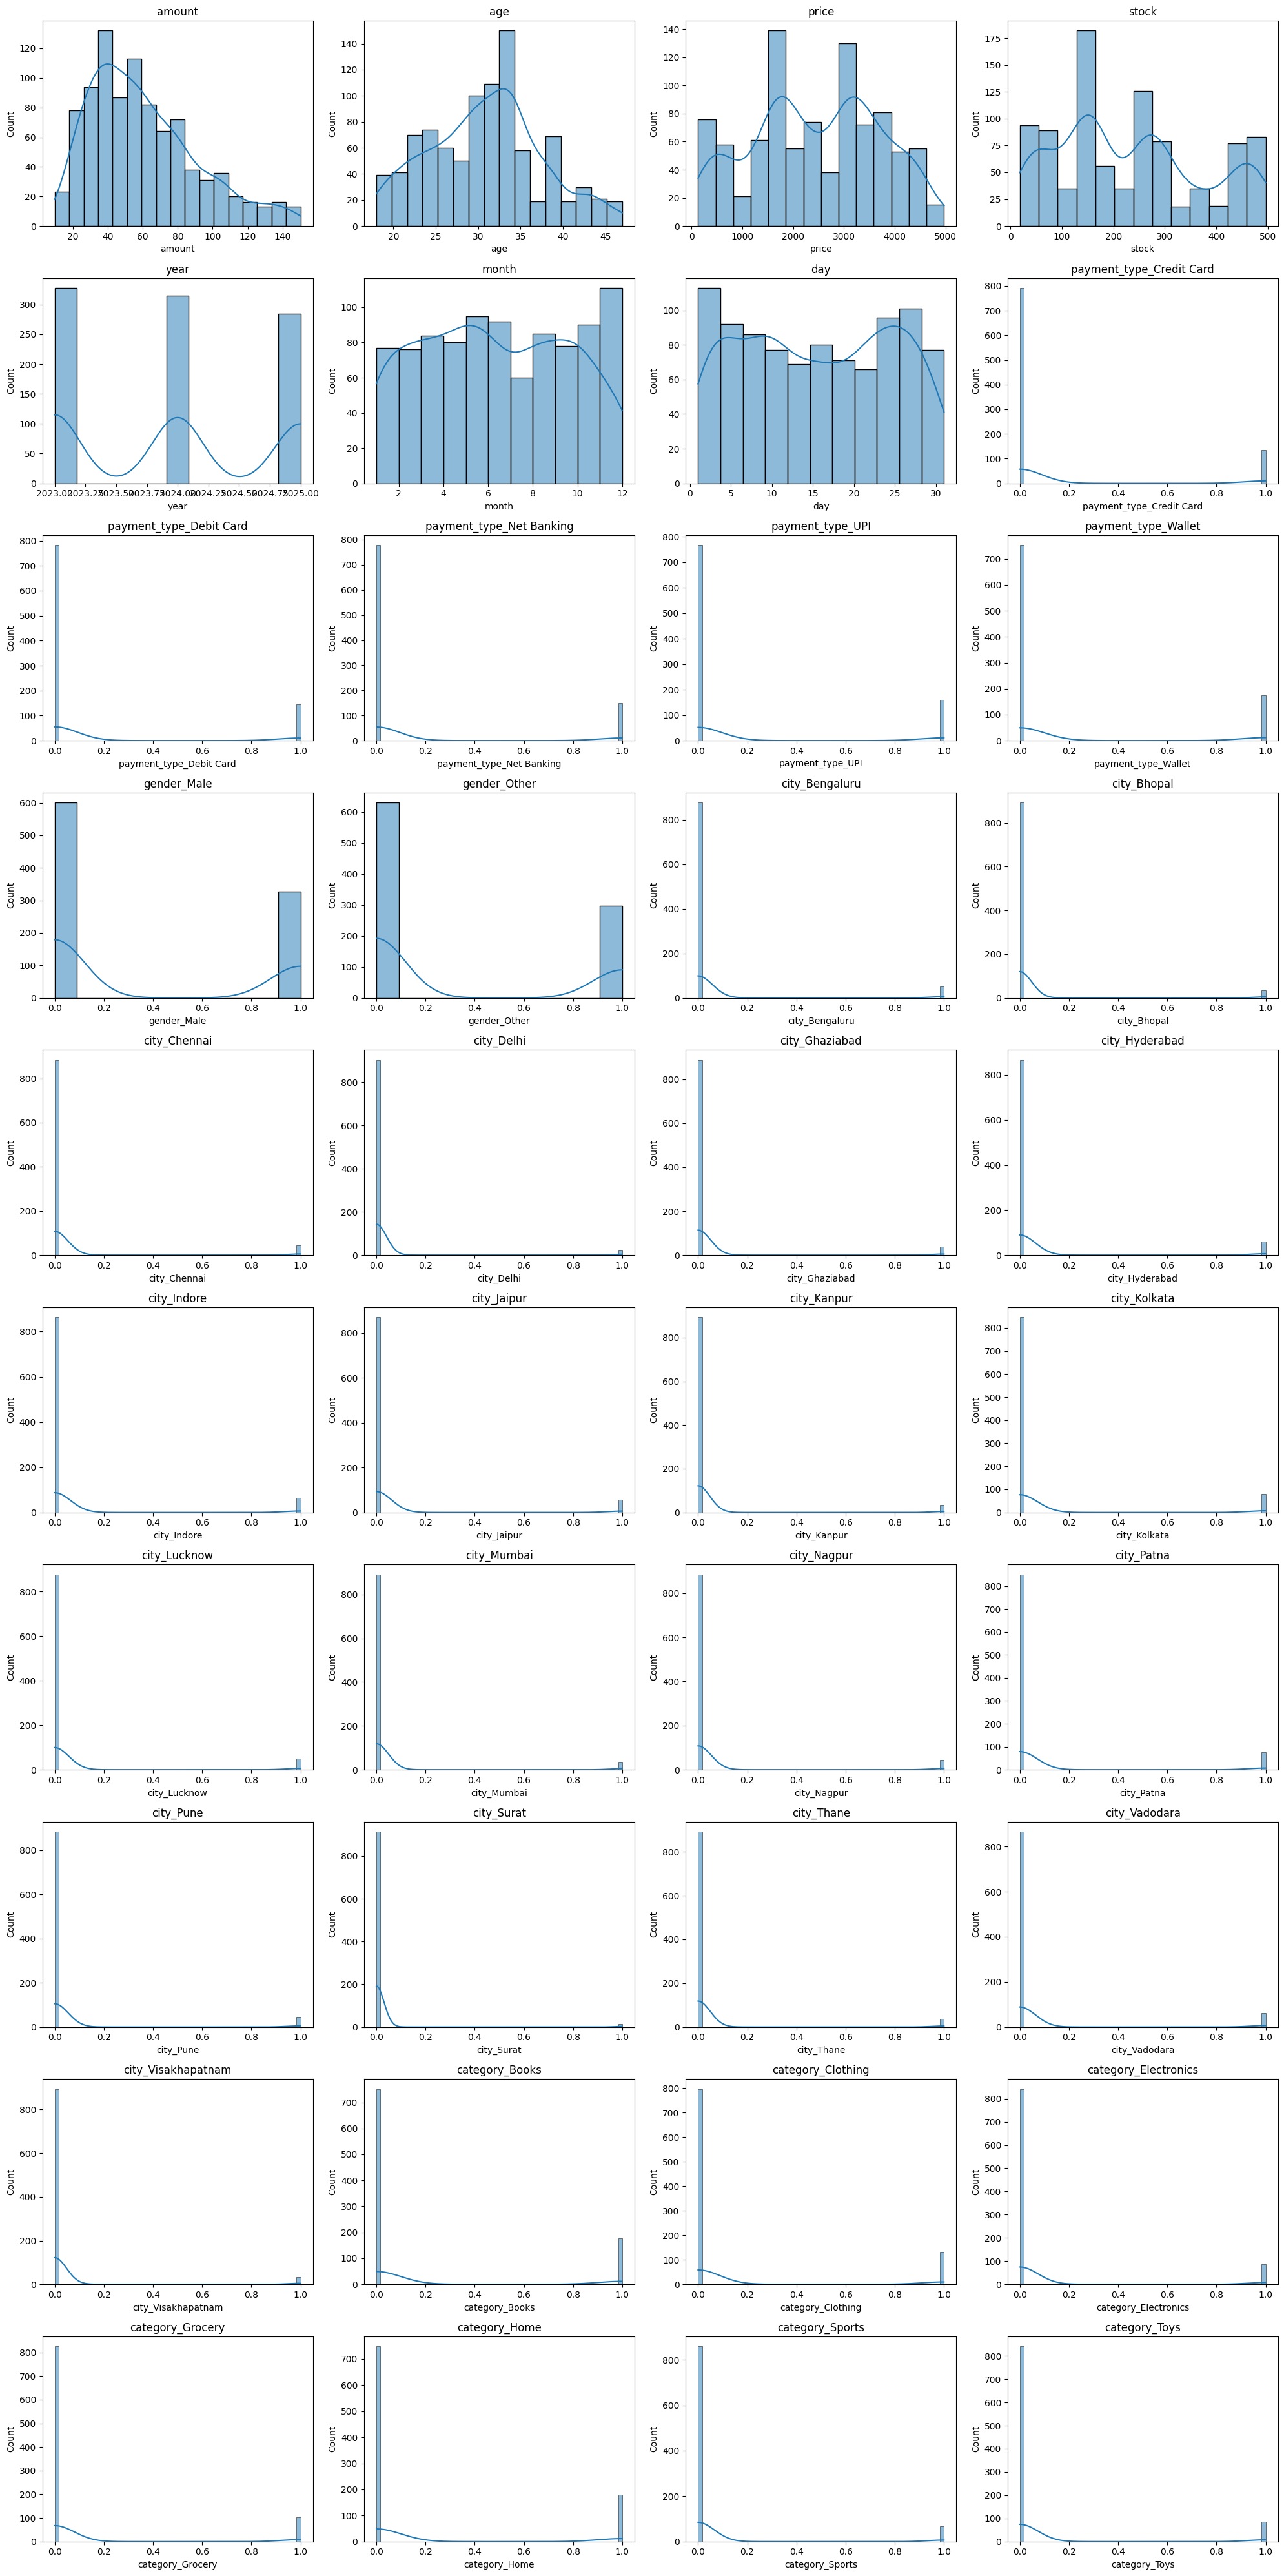

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_df = df.select_dtypes(include='number')

n_cols = 4
n_rows = math.ceil(len(numeric_df.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_df.columns):
    sns.histplot(numeric_df[col], kde=True, ax=ax)
    ax.set_title(col)

# hide any unused empty subplots
for ax in axes[len(numeric_df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()